In [2]:
%cd ../..

/home/jj/Research/ConceptualSensitivityRegularization


In [3]:
import numpy as np
from csr.module.dataset.rrclarc_datasets import CelebADataset, get_celeba_biased_dataset


/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [4]:
celeba_path = ['/media/disk1/Data/',]
artifact_path = 'configs/dataset/artifacts_celeba.json'

dataset = get_celeba_biased_dataset(
    data_paths=celeba_path,
    normalize_data=True,
    artifact_ids_file=artifact_path
)


Using subset
Chosen attribute Blond_Hair with id 9.
not blonde 14539
overall 20438
Chosen attribute Blond_Hair with id 9.
Using subset
Artifacts in train: 16
Artifacts in test: 90
Artifacts in val: 87


In [5]:
print(dataset.sample_ids_by_artifact.keys())
print([len(dataset.sample_ids_by_artifact[artifact_id]) for artifact_id in dataset.sample_ids_by_artifact.keys()])
print()
print(len(dataset.all_artifact_sample_ids))
print(len(dataset.clean_sample_ids))
print(len(dataset))
print()
print(len(set.intersection(set(dataset.all_artifact_sample_ids), set(dataset.idxs_val))))
print(len(set.intersection(set(dataset.all_artifact_sample_ids), set(dataset.idxs_test))))
print(len(set.intersection(set(dataset.all_artifact_sample_ids), set(dataset.idxs_train))))
print(len(set.intersection(set(dataset.clean_sample_ids), set(dataset.idxs_val))))
print(len(set.intersection(set(dataset.clean_sample_ids), set(dataset.idxs_test))))
print(len(set.intersection(set(dataset.clean_sample_ids), set(dataset.idxs_train))))
print()
print(len(np.intersect1d(dataset.all_artifact_sample_ids, dataset.idxs_val)))





dict_keys(['blonde_collar', 'not_blonde_collar', 'collar'])
[193, 1497, 1690]

3380
31790
33480

235
217
1238
3182
3200
25408

235


In [6]:
from torchvision.datasets import CelebA
ds = CelebA(
    root = '/media/disk1/Data/',
    split = 'all',
)

In [7]:
ATTR = "Blond_Hair"
ATTR2 = "Wearing_Necktie"
attr_id = np.where(np.array(ds.attr_names) == ATTR)[0][0]
attr_id2 = np.where(np.array(ds.attr_names) == ATTR2)[0][0]
USE_SUBSET = True
if USE_SUBSET:
    print("Using subset")
    NTH = 10
else:
    NTH = 1
filter_indices = np.zeros(len(ds.attr))


filter_indices[::NTH] = 1
print(f"Chosen attribute {ATTR} with id {attr_id}.")
labels = ds.attr[:, attr_id]
labels2 = ds.attr[:, attr_id2]
both = np.where(np.logical_and(labels, labels2) == 1)[0]
# print(both)
filter_indices[both] = 1

both_names = np.array(ds.filename)[both]
# print("', '".join(both_names) + "\n")

labels_not_blonde = 1 * (ds.attr[:, attr_id] == 0)
labels_collar = ds.attr[:, attr_id2]
not_blonde_collar = np.where(
    np.logical_and(labels_not_blonde, labels_collar) == 1
)[0]
print("not blonde", len(not_blonde_collar))
print("overall", np.sum(filter_indices == 1))
filter_indices[not_blonde_collar] = 1

labels = ds.attr[:, attr_id][filter_indices == 1]
labels2 = ds.attr[:, attr_id2][filter_indices == 1]
both = np.where(np.logical_and(labels, labels2) == 1)[0]
# print(both[:10])

labels_not_blonde = 1 * (ds.attr[:, attr_id][filter_indices == 1] == 0)
labels_collar = ds.attr[:, attr_id2][filter_indices == 1]
not_blonde_collar = np.where(
    np.logical_and(labels_not_blonde, labels_collar) == 1
)[0]

print(f"Chosen attribute {ATTR} with id {attr_id}.")

Using subset
Chosen attribute Blond_Hair with id 9.
not blonde 14539
overall 20438
Chosen attribute Blond_Hair with id 9.


In [8]:
dataset.metadata

,image_id,targets,blonde_collar
0,000001.jpg,0,False
1,000011.jpg,0,False
2,000015.jpg,0,False
3,000021.jpg,0,False
4,000031.jpg,0,False
...,...,...,...
33475,202571.jpg,0,False
33476,202581.jpg,0,False
33477,202586.jpg,0,False
33478,202588.jpg,0,False


In [9]:
dataset.metadata['targets'].value_counts()

targets
0    30300
1     3180
Name: count, dtype: int64

In [10]:
dataset.metadata['blonde_collar'].value_counts()

blonde_collar
False    33287
True       193
Name: count, dtype: int64

In [11]:
dataset.idxs_train

array([    1,     2,     3, ..., 33477, 33478, 33479])

In [12]:
dset_tr = dataset.get_subset_by_idxs(dataset.idxs_train)

In [14]:
dset_tr.metadata

,image_id,targets,blonde_collar
0,000011.jpg,0,False
1,000015.jpg,0,False
2,000021.jpg,0,False
3,000031.jpg,0,False
4,000032.jpg,0,False
...,...,...,...
26641,202561.jpg,0,False
26642,202571.jpg,0,False
26643,202586.jpg,0,False
26644,202588.jpg,0,False


In [47]:
def unnormalize(img):
    return img.permute(1,2,0) * 0.5 + 0.5


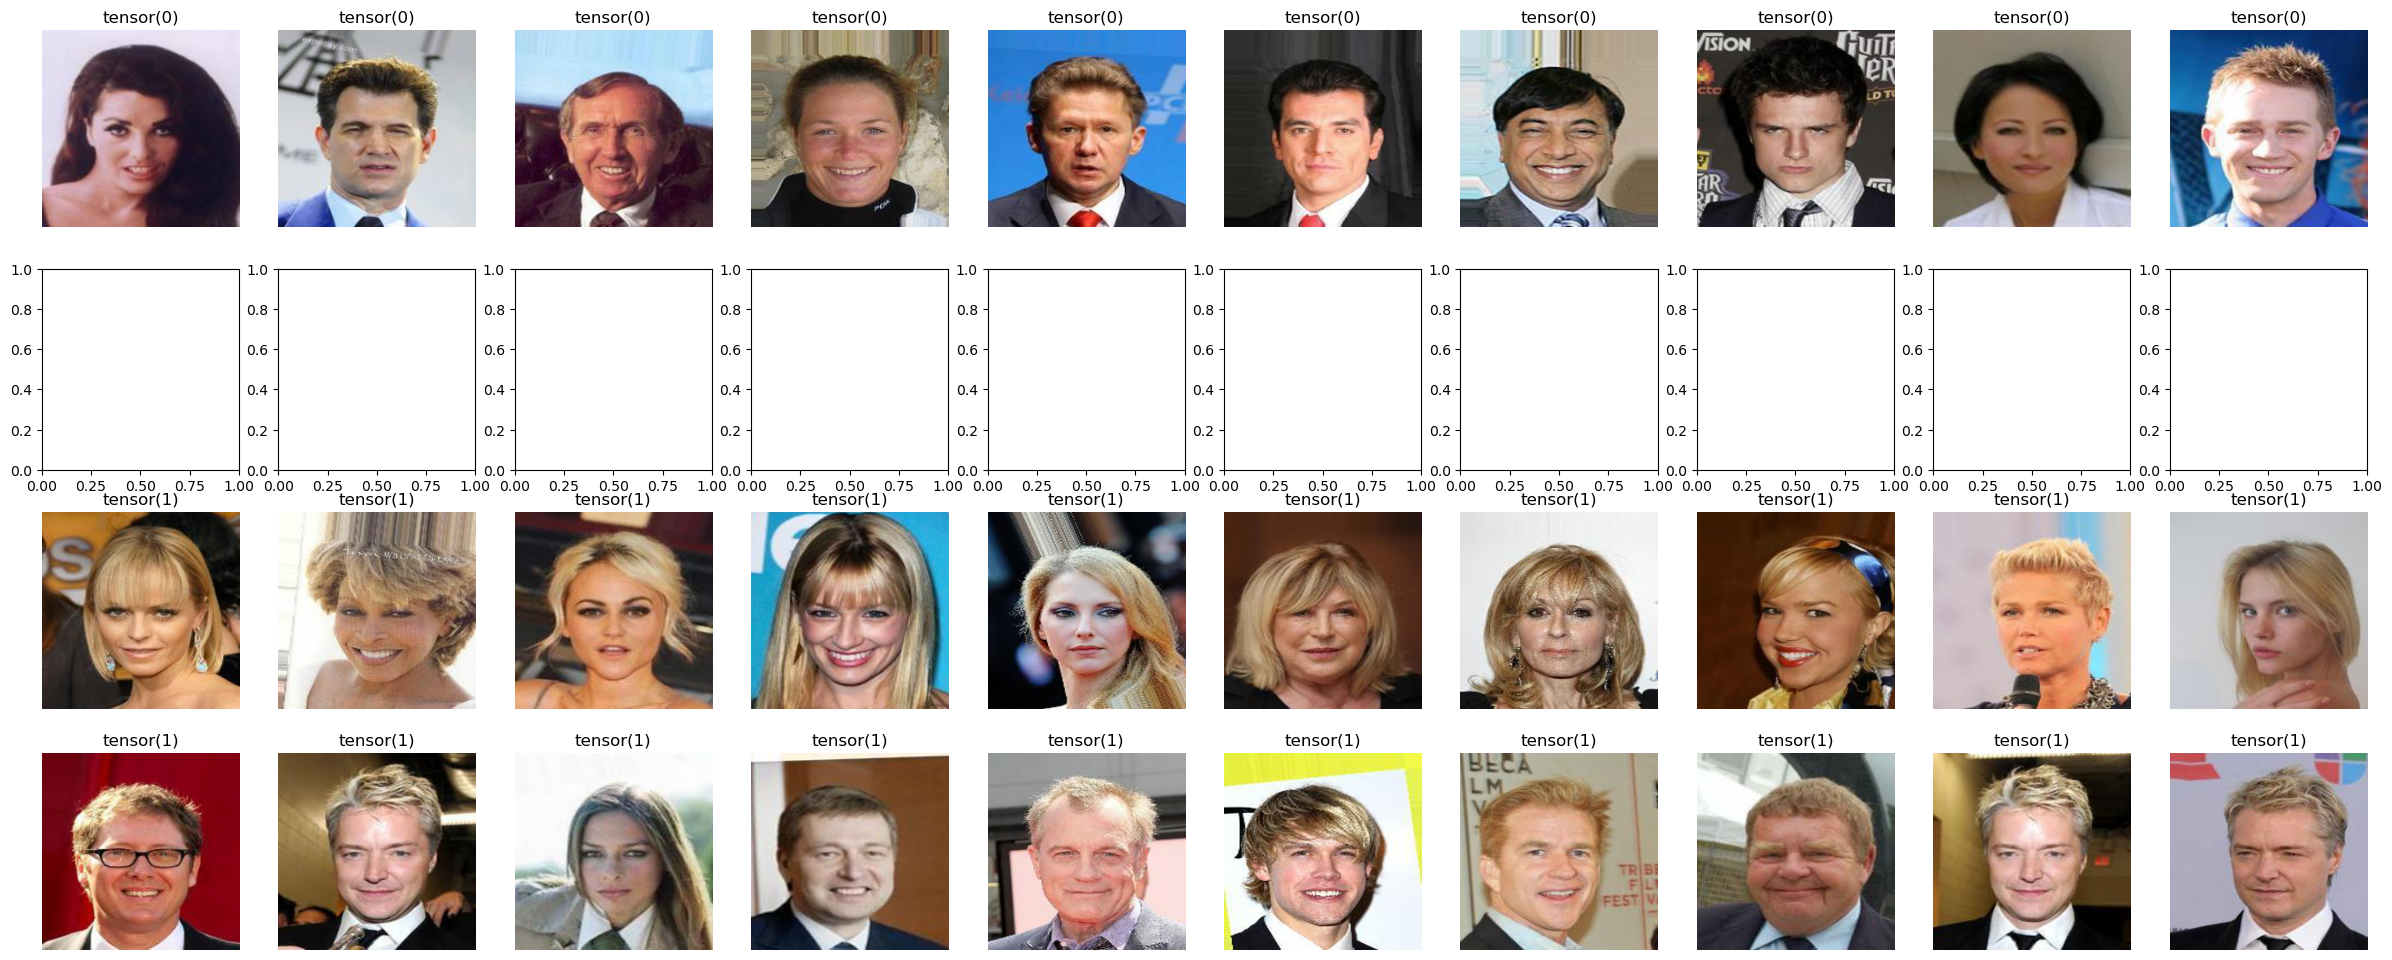

In [48]:
# plot some images in dataset_dict
from itertools import product
import matplotlib.pyplot as plt
import torchvision

fig, ax = plt.subplots(4, 10, figsize=(30, 12))

for tmp in [[0, 0], [0, 1], [1, 0], [1, 1]]:
    targets, blonde_collar = tmp
    row = targets * 2 + blonde_collar
    for col in range(10):
        idxs = dset_tr.metadata.query(f"targets == {targets} and blonde_collar == {blonde_collar}").index
        if len(idxs) == 0:
            continue

        img, label = dset_tr[idxs[col]]
        ax[row, col].imshow(unnormalize(img))
        ax[row, col].set_title(label)
        ax[row, col].axis('off')
plt.show()